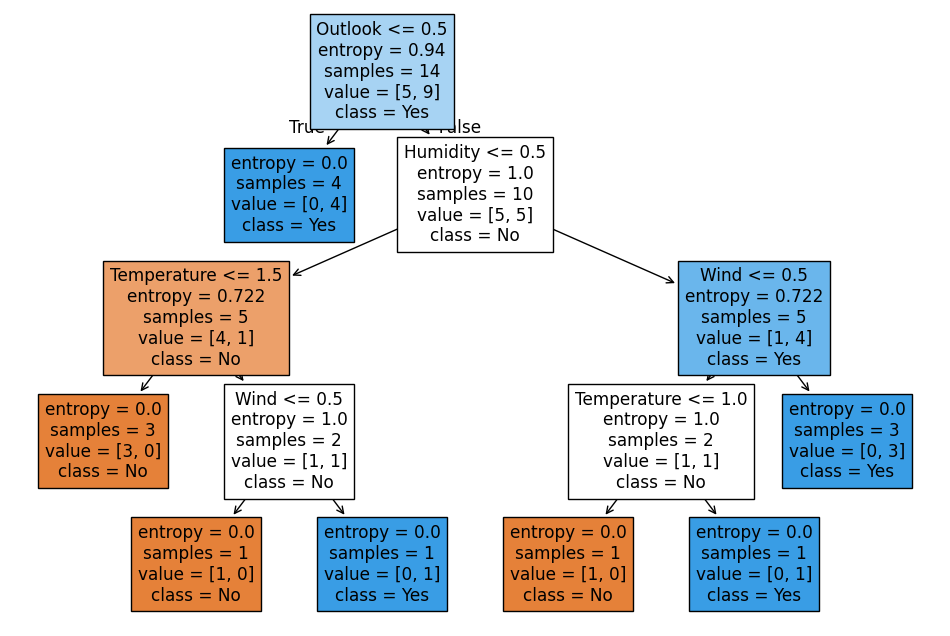

Accuracy: 1.0
Confusion Matrix:
 [[5 0]
 [0 9]]
Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import preprocessing
import matplotlib.pyplot as plt

# Dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Mild','Hot','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

# Convert categorical data into numbers
le = preprocessing.LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

# Features and Target
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

# Train Decision Tree
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

# Plot the tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

# Predictions
y_pred = model.predict(X)
# Evaluation

from sklearn.metrics import classification_report
cr = classification_report(y, y_pred, target_names=['No', 'Yes'])
from sklearn.metrics import accuracy_score, confusion_matrix
ac = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print("Accuracy:", ac)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)


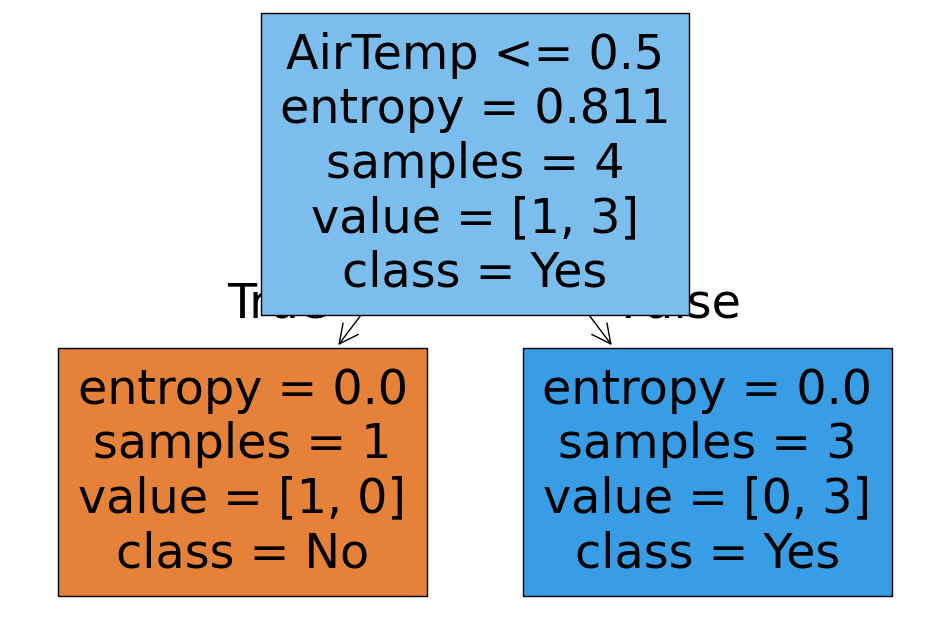

Confusion Matrix:
 [[1 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import preprocessing
import matplotlib.pyplot as plt

dataset = pd.read_csv('Play_tennis_dataset.csv')


# Convert categorical data into numbers
le = preprocessing.LabelEncoder()

for column in dataset.columns:
    dataset[column] = le.fit_transform(dataset [column])

# Features and Target
X = dataset.drop('PlayTennis', axis=1)
y = dataset['PlayTennis']

# Train Decision Tree
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

# Plot the tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

# add confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
cr = classification_report(y, y_pred, target_names=['No', 'Yes'])
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)

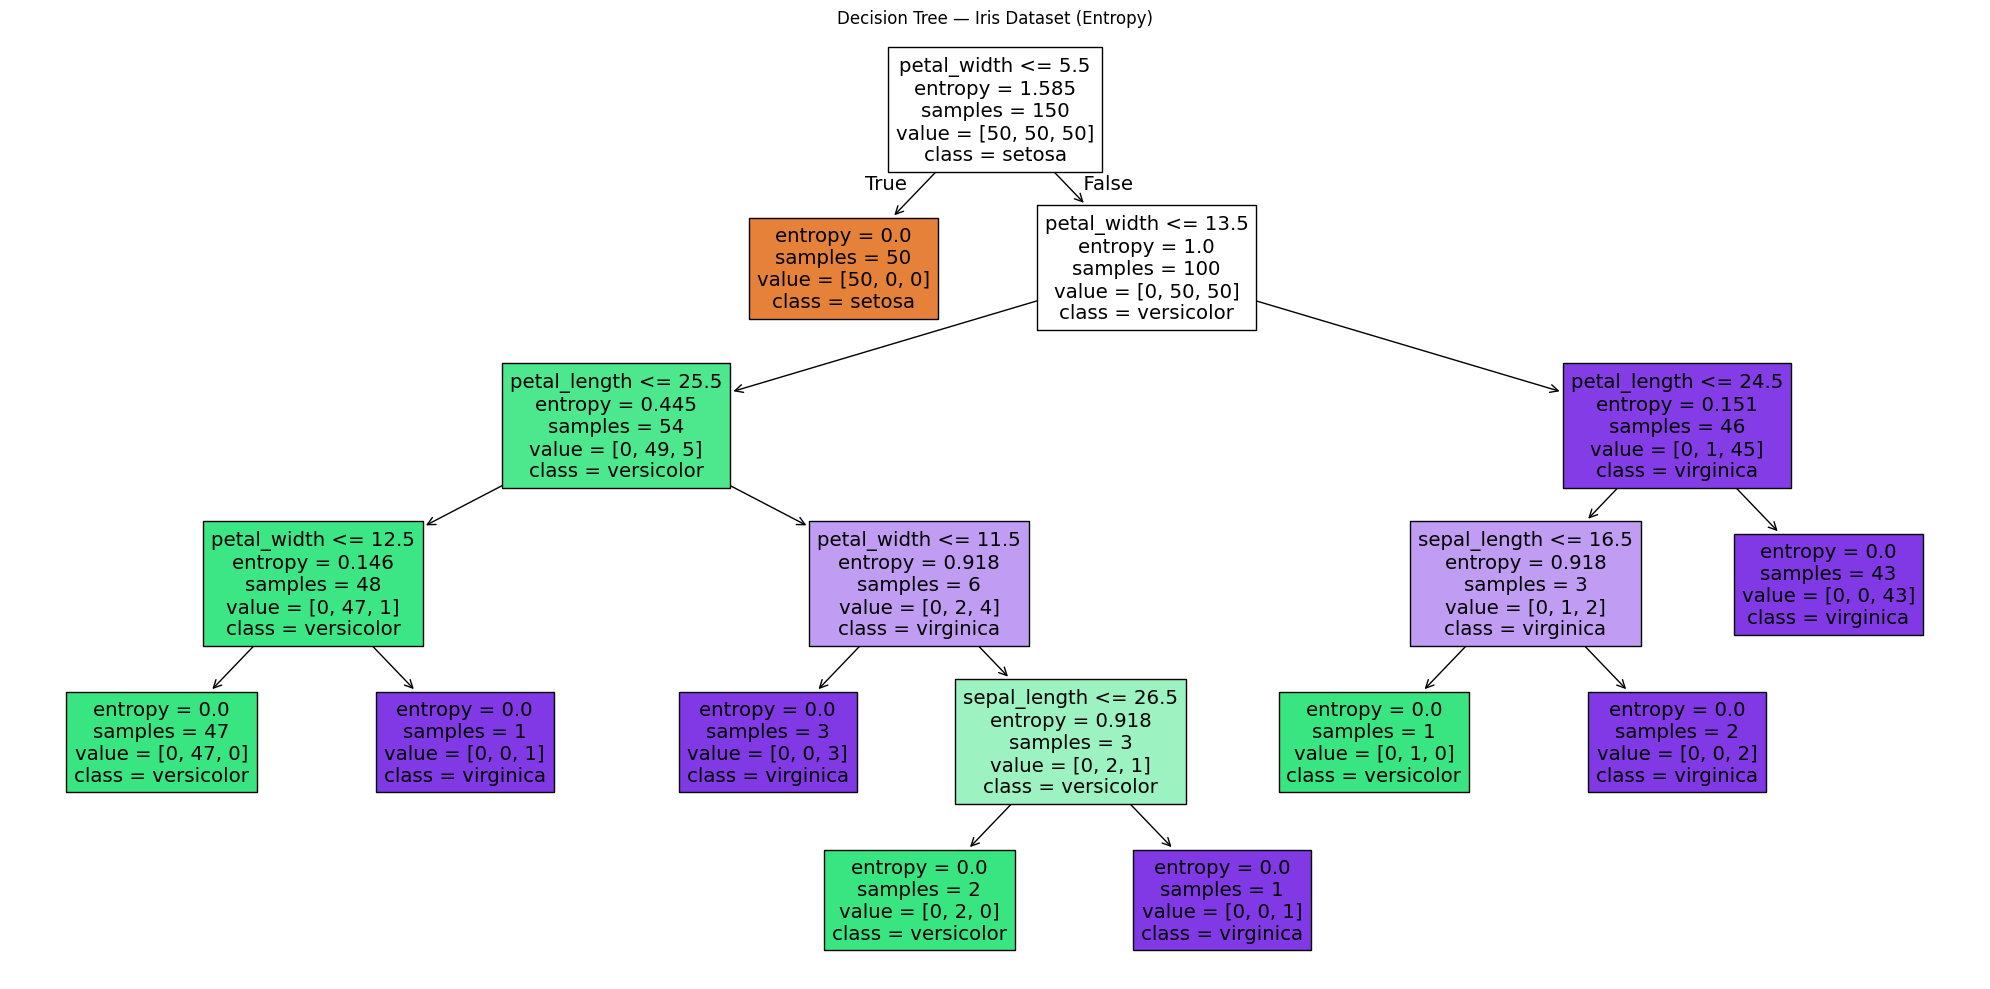

Training Accuracy: 100.0 %
Confusion Matrix:
 [[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       1.00      1.00      1.00        50
   virginica       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import preprocessing
import matplotlib.pyplot as plt

# Load the Iris CSV file
data = pd.read_csv('Iris.csv')
df = pd.DataFrame(data)

# Drop Id only if it exists
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Support both 'Species' and 'species'
target_col = 'Species' if 'Species' in df.columns else 'species'
class_names = sorted(df[target_col].unique())

le = preprocessing.LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

X = df.drop(target_col, axis=1)
Y = df[target_col]

model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, Y)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=class_names,  
    filled=True
)
plt.title("Decision Tree — Iris Dataset (Entropy)")
plt.tight_layout()
plt.savefig('iris_tree.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training Accuracy:", round(model.score(X, Y) * 100, 2), "%")

#add confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X)
cm = confusion_matrix(Y, y_pred)
cr = classification_report(Y, y_pred, target_names=class_names)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)